# Segmentación de clientes RFM · Mercado Verde

**Objetivo:** identificar qué grupos de clientes generan más valor, cuáles están en riesgo de irse y qué acción comercial conviene para cada uno.

**Contexto:** Mercado Verde es una tienda online **ficticia** de productos saludables en Colombia. Los datos son **simulados** y se crearon para este portafolio; no corresponden a ninguna empresa real.

**Método RFM:** cada cliente se califica de 1 a 5 en tres dimensiones:
- **R (Recencia):** hace cuántos días fue su última compra (menos días = mejor).
- **F (Frecuencia):** cuántos pedidos ha hecho.
- **M (Monetario):** cuánto ha gastado en total.

**Herramientas:** Python (pandas, numpy, matplotlib, seaborn).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x:,.1f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10})
COLOR = "#2A9D8F"; OSCURO = "#1F3A4D"; GRIS = "#A9B7C0"

## 1. Datos

Se simulan dos años de pedidos (2024–2025). A propósito se incluyen problemas típicos de una base real (duplicados, clientes sin identificar y devoluciones con valor negativo) para mostrar el proceso de limpieza.

In [2]:
rng = np.random.default_rng(7)
n_clientes = 4000
inicio, fin = pd.Timestamp("2024-01-01"), pd.Timestamp("2025-12-31")
dias = (fin - inicio).days

# Cada cliente tiene un tipo de comportamiento que define su frecuencia, ticket y cuándo dejó de comprar
tipos = rng.choice(["frecuente", "ocasional", "unica_vez", "perdido"], size=n_clientes, p=[0.18, 0.37, 0.25, 0.20])
filas = []
for i, tipo in enumerate(tipos, start=1):
    cid = f"C{i:05d}"
    alta = rng.integers(0, dias - 30)
    if tipo == "frecuente":
        n, ticket, fin_c = rng.poisson(14) + 4, rng.normal(115000, 25000), dias
    elif tipo == "ocasional":
        n, ticket, fin_c = rng.poisson(4) + 2, rng.normal(85000, 20000), dias
    elif tipo == "unica_vez":
        n, ticket, fin_c = 1, rng.normal(70000, 20000), dias
    else:  # perdido: compró varias veces y dejó de comprar
        n, ticket, fin_c = rng.poisson(5) + 2, rng.normal(95000, 25000), min(dias, alta + rng.integers(60, 300))
    fechas = inicio + pd.to_timedelta(np.sort(rng.integers(alta, max(fin_c, alta + 1), size=n)), unit="D")
    for f in fechas:
        filas.append([cid, f, max(15000, round(rng.normal(ticket, ticket * 0.25), -2))])

pedidos = pd.DataFrame(filas, columns=["cliente_id", "fecha", "valor"])
pedidos.insert(0, "pedido_id", [f"P{i:06d}" for i in range(1, len(pedidos) + 1)])

# Problemas de calidad de datos
duplicados = pedidos.sample(300, random_state=1)
sin_id = pedidos.sample(150, random_state=2).assign(cliente_id=np.nan)
devoluciones = pedidos.sample(200, random_state=3).assign(valor=lambda d: -d.valor)
pedidos = pd.concat([pedidos, duplicados, sin_id, devoluciones], ignore_index=True)

print(f"Registros: {len(pedidos):,}")
pedidos.head()

Registros: 28,965


,pedido_id,cliente_id,fecha,valor
0,P000001,C00001,2025-10-22,"37,400.0"
1,P000002,C00002,2024-05-24,"60,000.0"
2,P000003,C00002,2024-06-28,"70,400.0"
3,P000004,C00002,2024-07-29,"49,600.0"
4,P000005,C00002,2024-08-14,"136,900.0"


## 2. Limpieza de datos

In [3]:
print("Filas duplicadas:", pedidos.duplicated().sum())
print("Pedidos sin cliente:", pedidos.cliente_id.isna().sum())
print("Valores negativos (devoluciones):", (pedidos.valor < 0).sum())

limpio = (pedidos
          .drop_duplicates()                 # quita registros repetidos
          .dropna(subset=["cliente_id"])     # sin cliente no se puede segmentar
          .query("valor > 0"))               # se excluyen las devoluciones del análisis de compras

print(f"\nRegistros después de limpiar: {len(limpio):,} "
      f"({len(pedidos) - len(limpio):,} eliminados)")

Filas duplicadas: 300
Pedidos sin cliente: 150
Valores negativos (devoluciones): 200

Registros después de limpiar: 28,315 (650 eliminados)


## 3. Cálculo de RFM

La fecha de corte es el 1 de enero de 2026. Los puntajes van de 1 a 5 según quintiles: el 20 % de clientes con mejor resultado recibe 5.

In [4]:
fecha_corte = pd.Timestamp("2026-01-01")

rfm = limpio.groupby("cliente_id").agg(
    recencia=("fecha", lambda f: (fecha_corte - f.max()).days),
    frecuencia=("pedido_id", "nunique"),
    monetario=("valor", "sum"))

# rank(method="first") evita empates al cortar en quintiles
rfm["R"] = pd.qcut(rfm.recencia.rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm.frecuencia.rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm.monetario.rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm.head()

,recencia,frecuencia,monetario,R,F,M
cliente_id,,,,,,
C00001,71,1,"37,400.0",3,1,1
C00002,410,9,"733,700.0",1,4,4
C00003,336,1,"63,800.0",1,1,1
C00004,4,5,"581,200.0",5,2,3
C00005,59,9,"711,100.0",3,4,4


## 4. Segmentos

Las reglas combinan la recencia (R) con el promedio de frecuencia y valor (FM):

| Segmento | Regla | Qué significa |
|---|---|---|
| Campeones | R ≥ 4 y FM ≥ 4 | Compran seguido, mucho y hace poco |
| Leales | R ≥ 3 y FM ≥ 3 | Buenos clientes constantes |
| Nuevos o prometedores | R ≥ 4 y FM < 3 | Compraron hace poco, pero poco |
| No se pueden perder | R ≤ 2 y FM ≥ 4 | Eran de los mejores y dejaron de comprar |
| En riesgo | R ≤ 2 y FM ≥ 2,5 | Compraban bien, pero se están alejando |
| Necesitan atención | R = 3 y FM < 3 | Clientes promedio que se pueden enfriar |
| Perdidos | El resto | Compraron poco y hace mucho |

In [5]:
def segmento(fila):
    r, fm = fila.R, (fila.F + fila.M) / 2
    if r >= 4 and fm >= 4: return "Campeones"
    if r >= 3 and fm >= 3: return "Leales"
    if r >= 4:             return "Nuevos o prometedores"
    if r <= 2 and fm >= 4: return "No se pueden perder"
    if r <= 2 and fm >= 2.5: return "En riesgo"
    if r == 3:             return "Necesitan atención"
    return "Perdidos"

rfm["segmento"] = rfm.apply(segmento, axis=1)

resumen = (rfm.groupby("segmento")
           .agg(clientes=("R", "size"), recencia_prom=("recencia", "mean"),
                pedidos_prom=("frecuencia", "mean"), gasto_prom=("monetario", "mean"),
                ventas=("monetario", "sum"))
           .sort_values("ventas", ascending=False))
resumen["% clientes"] = resumen.clientes / resumen.clientes.sum() * 100
resumen["% ventas"] = resumen.ventas / resumen.ventas.sum() * 100
resumen

,clientes,recencia_prom,pedidos_prom,gasto_prom,ventas,% clientes,% ventas
segmento,,,,,,,
Campeones,807,12.6,15.1,"1,692,261.7","1,365,655,200.0",20.2,48.4
Leales,786,34.7,8.5,"822,015.3","646,104,000.0",19.7,22.9
No se pueden perder,305,280.9,9.4,"946,500.3","288,682,600.0",7.6,10.2
En riesgo,502,251.9,5.9,"510,364.3","256,202,900.0",12.6,9.1
Nuevos o prometedores,436,16.6,3.2,"242,483.7","105,722,900.0",10.9,3.7
Perdidos,793,257.3,1.6,"115,874.7","91,888,600.0",19.8,3.3
Necesitan atención,371,55.9,2.5,"186,404.9","69,156,200.0",9.3,2.4


## 5. Visualización

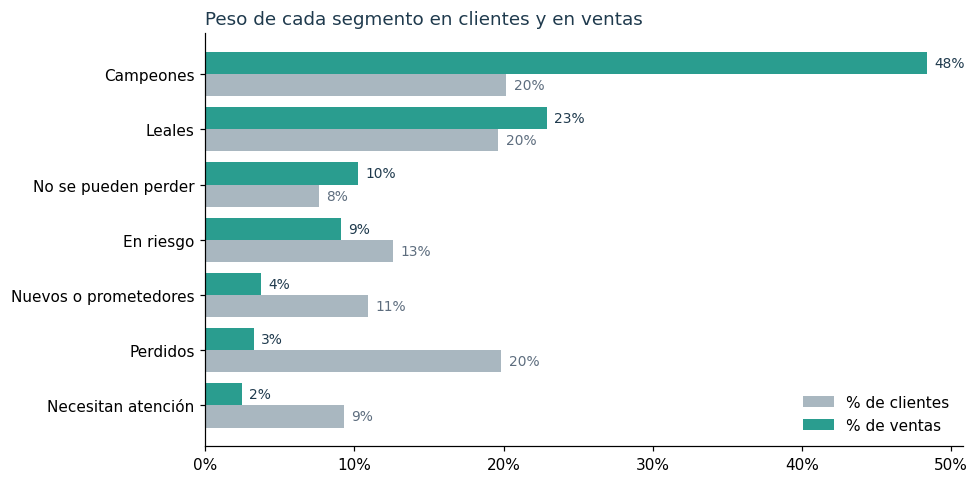

In [6]:
orden = resumen.index
fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(orden))
ax.barh(y + 0.2, resumen["% clientes"], height=0.4, color=GRIS, label="% de clientes")
ax.barh(y - 0.2, resumen["% ventas"], height=0.4, color=COLOR, label="% de ventas")
ax.set_yticks(y, orden); ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
for i, (c, v) in enumerate(zip(resumen["% clientes"], resumen["% ventas"])):
    ax.text(v + 0.5, i - 0.2, f"{v:.0f}%", va="center", fontsize=9, color=OSCURO)
    ax.text(c + 0.5, i + 0.2, f"{c:.0f}%", va="center", fontsize=9, color="#5D6D7E")
ax.set_title("Peso de cada segmento en clientes y en ventas", loc="left", fontsize=12, color=OSCURO)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

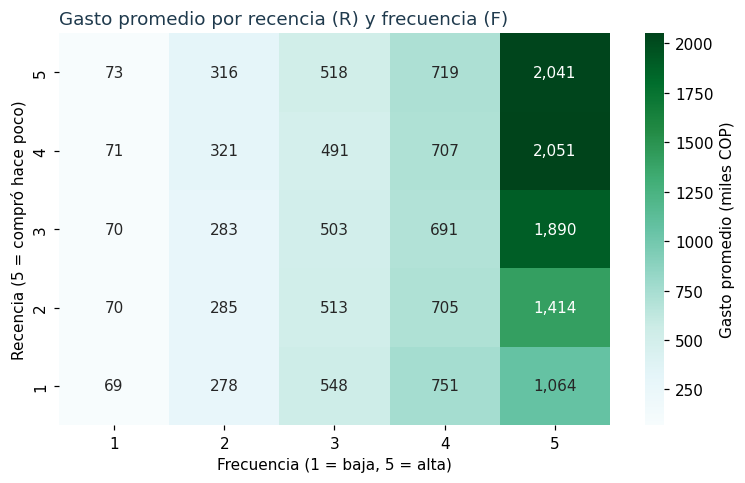

In [7]:
mapa = rfm.pivot_table(index="R", columns="F", values="monetario", aggfunc="mean") / 1000
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(mapa.sort_index(ascending=False), annot=True, fmt=",.0f", cmap="BuGn",
            cbar_kws={"label": "Gasto promedio (miles COP)"}, ax=ax)
ax.set_title("Gasto promedio por recencia (R) y frecuencia (F)", loc="left", fontsize=12, color=OSCURO)
ax.set_xlabel("Frecuencia (1 = baja, 5 = alta)"); ax.set_ylabel("Recencia (5 = compró hace poco)")
plt.tight_layout(); plt.show()

## 6. Hallazgos

In [8]:
total = resumen.ventas.sum()
top = resumen.loc["Campeones"]
leal = resumen.loc["Leales"]
riesgo = resumen.loc[["En riesgo", "No se pueden perder"]]
nuevos = resumen.loc["Nuevos o prometedores"]

print(f"1. Los Campeones son el {top['% clientes']:.0f} % de los clientes, pero generan el {top['% ventas']:.0f} % de las ventas.")
print(f"   Junto con los Leales suman el {top['% ventas'] + leal['% ventas']:.0f} % de las ventas.")
print(f"2. {int(riesgo.clientes.sum()):,} clientes valiosos se están alejando (En riesgo + No se pueden perder):")
print(f"   representan COP {riesgo.ventas.sum() / 1e6:,.0f} millones en compras históricas ({riesgo['% ventas'].sum():.0f} % del total).")
print(f"3. Hay {int(nuevos.clientes):,} clientes nuevos o prometedores, con un gasto promedio de COP {nuevos.gasto_prom:,.0f}.")
print(f"   La oportunidad es lograr su segunda y tercera compra.")
print(f"4. Un Campeón gasta en promedio {top.gasto_prom / resumen.loc['Perdidos'].gasto_prom:.0f} veces más que un cliente Perdido.")

1. Los Campeones son el 20 % de los clientes, pero generan el 48 % de las ventas.
   Junto con los Leales suman el 71 % de las ventas.
2. 807 clientes valiosos se están alejando (En riesgo + No se pueden perder):
   representan COP 545 millones en compras históricas (19 % del total).
3. Hay 436 clientes nuevos o prometedores, con un gasto promedio de COP 242,484.
   La oportunidad es lograr su segunda y tercera compra.
4. Un Campeón gasta en promedio 15 veces más que un cliente Perdido.


## 7. Recomendaciones

| Segmento | Acción sugerida |
|---|---|
| **Campeones** | Programa de fidelización, acceso anticipado a lanzamientos y pedirles reseñas o referidos. |
| **Leales** | Venta cruzada con productos complementarios y beneficios por volumen. |
| **Nuevos o prometedores** | Secuencia de bienvenida y un incentivo para la segunda compra en los primeros 30 días. |
| **En riesgo / No se pueden perder** | Campaña de reactivación personalizada (descuento o contacto directo) y encuesta para entender por qué se alejaron. |
| **Necesitan atención** | Recordatorios de recompra según su ciclo habitual. |
| **Perdidos** | Una última campaña de bajo costo; si no responden, no invertir más en ellos. |

**Siguiente paso:** medir el efecto de cada acción con un grupo de control, para saber qué campaña realmente aumenta las ventas.

In [9]:
# Exportar la segmentación para usarla en Excel, Power BI o el CRM
rfm.reset_index().to_csv("segmentacion_rfm_clientes.csv", index=False, encoding="utf-8-sig")
print("Archivo exportado: segmentacion_rfm_clientes.csv")

Archivo exportado: segmentacion_rfm_clientes.csv
